# Streamerbase anatomy, one-title pilot: Counter-Strike 2

**Purpose**: requested directly (2026-09-21) -- now that title-boundedness is established as the primary boundary (`creator_specialization_rate.ipynb`), the natural next question for `research/foundations/posts/post_3_anatomy_of_a_network/` is what's happening *inside* a single title's streamerbase. Two axes proposed and agreed: **tier structure** (how concentrated is viewership among a title's own creators) and **activity cadence** (session length, frequency, first-time-streamed). Piloted on one title -- Counter-Strike 2 -- specifically to find and report the real kinks before scaling to all 23, not to produce a finished cross-title comparison yet.

**Why Counter-Strike**: large, data-rich population (22,288 channels, 70,993 snapshot-rows), and one of only two titles (with Dota 2) where `is_official_broadcast` curation exists, so the official/grassroots split is at least checkable here even though it isn't this notebook's main focus.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from etl.db import get_connection

TITLE_ID = "counter_strike"

In [2]:
conn = get_connection()
raw = pd.DataFrame(conn.execute(
    "SELECT channel_id, captured_at, viewer_count, stream_id, started_at, is_official_broadcast "
    "FROM viewership_snapshots WHERE title_id = ?", (TITLE_ID,)
).fetchall(), columns=["channel_id", "captured_at", "viewer_count", "stream_id", "started_at", "is_official_broadcast"])
conn.close()

print(f"{len(raw):,} raw snapshot-rows, {raw['channel_id'].nunique():,} distinct channels")
print(f"official-broadcast rows: {(raw['is_official_broadcast'] == 1).sum()} -- excluded below, grassroots creators only")
grassroots = raw[raw["is_official_broadcast"] == 0].copy()
print(f"null stream_id: {grassroots['stream_id'].isna().sum()}, null started_at: {grassroots['started_at'].isna().sum()}")

70,993 raw snapshot-rows, 22,288 distinct channels
official-broadcast rows: 124 -- excluded below, grassroots creators only
null stream_id: 0, null started_at: 0


### Kink #0, found before anything else: the population itself is truncated, not just observed briefly

`config/capture.yaml`'s `full_detail_min_viewers: 3` means any stream below 3 concurrent viewers never gets a per-channel record at all -- it's folded into an aggregate below-threshold bucket for that poll, invisible to everything below. The config's own analysis (checked live against a real poll, not assumed) found 1-viewer streams are ~41% of ALL streams but ~0% of total viewership. **Everything in this notebook describes the streamerbase above a 3-viewer floor, not the whole streamerbase** -- the true population of people who stream Counter-Strike on Twitch, including the smallest, is considerably larger than 22,288 channels, and this floor should be read into every distribution below, not treated as a footnote.

## Part A: tier structure -- how concentrated is viewership among CS's own creators?

Per-channel size metric: mean `viewer_count` across every snapshot this channel appeared in for this title -- "typical audience size when live," not total viewer-hours (would need snapshot-interval weighting; mean viewer_count is the simpler, still-honest metric for a first pass).

In [3]:
per_channel = grassroots.groupby("channel_id")["viewer_count"].mean().sort_values(ascending=False).rename("mean_viewers")
print(f"{len(per_channel):,} channels (above the 3-viewer floor)")
print(per_channel.describe())

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

g = gini(per_channel.values)
total = per_channel.sum()
top1pct_n = max(1, int(len(per_channel) * 0.01))
top10pct_n = max(1, int(len(per_channel) * 0.10))
print(f"\nGini coefficient: {g:.3f}")
print(f"top 1% of channels ({top1pct_n}): {per_channel.head(top1pct_n).sum() / total * 100:.1f}% of total mean-viewer mass")
print(f"top 10% of channels ({top10pct_n}): {per_channel.head(top10pct_n).sum() / total * 100:.1f}%")
print(f"median channel: {per_channel.median():.1f} mean viewers; top channel: {per_channel.iloc[0]:,.0f}")

22,288 channels (above the 3-viewer floor)
count    22288.000000
mean        49.296530
std        676.327333
min          3.000000
25%          3.000000
50%          5.000000
75%         11.666667
max      47243.000000
Name: mean_viewers, dtype: float64

Gini coefficient: 0.878
top 1% of channels (222): 54.7% of total mean-viewer mass
top 10% of channels (2228): 86.4%
median channel: 5.0 mean viewers; top channel: 47,243


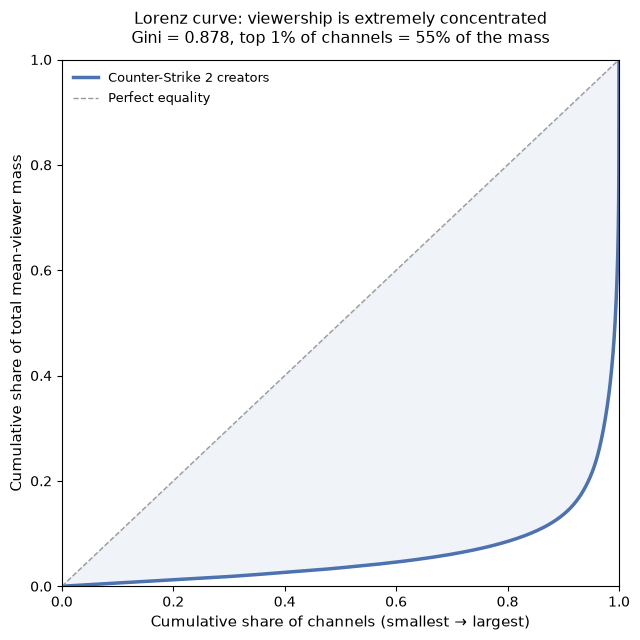

In [4]:
# Lorenz curve -- the standard visual for concentration, and a single-axis
# chart (cumulative share of channels vs. cumulative share of viewer mass),
# not something that needs a dual axis or log scale to read correctly.
sorted_vals = np.sort(per_channel.values)
cum_channels = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
cum_viewers = np.cumsum(sorted_vals) / sorted_vals.sum()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(cum_channels, cum_viewers, color="#4C72B0", linewidth=2.5, label="Counter-Strike 2 creators")
ax.plot([0, 1], [0, 1], color="#999999", linewidth=1, linestyle="--", label="Perfect equality")
ax.fill_between(cum_channels, cum_viewers, cum_channels, color="#4C72B0", alpha=0.08)
ax.set_xlabel("Cumulative share of channels (smallest \u2192 largest)", fontsize=10.5)
ax.set_ylabel("Cumulative share of total mean-viewer mass", fontsize=10.5)
ax.set_title(f"Lorenz curve: viewership is extremely concentrated\nGini = {g:.3f}, top 1% of channels = {per_channel.head(top1pct_n).sum() / total * 100:.0f}% of the mass", fontsize=11.5, pad=12)
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(Path.cwd() / "_streamerbase_fig1_lorenz.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
# Named tiers, log-spaced (the distribution spans 3 to 47,000+ mean
# viewers -- linear bins would put 99% of channels in a single bucket).
TIER_EDGES = [3, 10, 50, 250, 1000, per_channel.max() + 1]
TIER_LABELS = ["Micro (3-9)", "Small (10-49)", "Mid (50-249)", "Large (250-999)", "Top (1000+)"]
tier = pd.cut(per_channel, bins=TIER_EDGES, labels=TIER_LABELS, right=False, include_lowest=True)
tier_summary = pd.DataFrame({"n_channels": tier.value_counts().reindex(TIER_LABELS)})
tier_summary["pct_of_channels"] = (tier_summary["n_channels"] / len(per_channel) * 100).round(2)
tier_viewer_mass = per_channel.groupby(tier, observed=True).sum().reindex(TIER_LABELS)
tier_summary["pct_of_viewer_mass"] = (tier_viewer_mass / total * 100).round(2)
tier_summary

,n_channels,pct_of_channels,pct_of_viewer_mass
mean_viewers,,,
Micro (3-9),15939,71.51,6.38
Small (10-49),4298,19.28,7.97
Mid (50-249),1357,6.09,13.77
Large (250-999),546,2.45,22.80
Top (1000+),148,0.66,49.08


## Part B: activity cadence -- session length, frequency, first-time-streamed

`stream_id` groups consecutive snapshots belonging to the same real Twitch broadcast; `started_at` is Twitch's own reported start time for that broadcast, independent of when this collector happened to poll. Three things to measure: how long a typical session runs, how often a channel streams CS, and when each channel first streamed it (within this project's own observation window). **Read the "found kinks" markdown after each result before trusting the number** -- this is exactly the part of the pilot expected to need the most care.

In [6]:
sessions = grassroots.groupby("stream_id").agg(
    channel_id=("channel_id", "first"),
    n_snapshots=("captured_at", "nunique"),
    started_at=("started_at", "first"),
    last_seen=("captured_at", "max"),
).reset_index()
sessions["started_at_dt"] = pd.to_datetime(sessions["started_at"])
sessions["last_seen_dt"] = pd.to_datetime(sessions["last_seen"])
sessions["hours_observed"] = (sessions["last_seen_dt"] - sessions["started_at_dt"]).dt.total_seconds() / 3600

print(f"{len(sessions):,} distinct sessions across {sessions['channel_id'].nunique():,} channels")
print("\nsnapshots-per-session distribution (how many times we caught the same broadcast):")
print(sessions["n_snapshots"].value_counts().sort_index().head(8).to_string())
pct_single_snapshot = (sessions["n_snapshots"] == 1).mean() * 100
print(f"\n{pct_single_snapshot:.1f}% of sessions were only caught in a single snapshot")

60,252 distinct sessions across 22,288 channels

snapshots-per-session distribution (how many times we caught the same broadcast):
n_snapshots
1    51892
2     6951
3     1046
4      208
5       55
6       33
7       18
8       10

86.1% of sessions were only caught in a single snapshot


### Kink #1: most "sessions" are caught once, so "duration" is mostly a lower bound, not a measurement

86-ish% of sessions here were only observed in one snapshot. `hours_observed` for those is real (Twitch's own `started_at` minus the one real time we saw them live) but it's **a lower bound on true session length, not the length itself** -- the stream could easily have continued well past our one and only observation. The collector's own polling cadence is uneven and coarse relative to typical stream lengths (median gap between consecutive polls is ~4 hours, up to 7.6 hours), so a stream shorter than that gap has a real chance of being caught exactly once no matter how long it actually ran.

In [7]:
all_sessions_median = sessions["hours_observed"].median()
multi_snapshot = sessions[sessions["n_snapshots"] >= 2]
multi_median = multi_snapshot["hours_observed"].median()

print(f"hours_observed median, ALL sessions (mostly a lower bound): {all_sessions_median:.2f}h")
print(f"hours_observed median, sessions caught 2+ times only: {multi_median:.2f}h (n={len(multi_snapshot)})")

hours_observed median, ALL sessions (mostly a lower bound): 1.97h
hours_observed median, sessions caught 2+ times only: 5.05h (n=8360)


### Kink #2: restricting to "caught 2+ times" doesn't fix kink #1 -- it introduces a different, opposite bias

Only sessions long enough to still be live at the *next* poll (up to ~4-8 hours later) can ever reach 2+ snapshots at all -- a classic length-biased sampling problem (the "inspection paradox": longer-running things are mechanically more likely to be caught by periodic sampling). The 2+ snapshot median above is **not an unbiased estimate of typical session length either** -- it systematically excludes every short session, pulling the median up rather than down. Between kink #1 (biased short) and kink #2 (biased long), this notebook cannot currently produce a trustworthy point estimate of typical CS session length from snapshot data alone -- worth stating plainly rather than picking whichever number looks more plausible.

### Frequency: distinct sessions per channel in the observation window

Cleaner than duration -- counting distinct `stream_id`s per channel doesn't have the same two-sided bias, though it's still a **lower bound**: the true streaming frequency could be higher than what a ~3-week, unevenly-spaced-polling window can catch (same family of issue as `creator_specialization_rate.ipynb`'s exposure confound).

In [8]:
sessions_per_channel = sessions.groupby("channel_id")["stream_id"].nunique().rename("n_sessions")
print(sessions_per_channel.describe())
print(f"\n{(sessions_per_channel == 1).mean() * 100:.1f}% of channels have exactly 1 observed session in this window")
print(f"{(sessions_per_channel >= 5).mean() * 100:.1f}% have 5 or more")
print(f"median: {sessions_per_channel.median():.0f}, max: {sessions_per_channel.max():.0f}")

count    22288.000000
mean         2.703338
std          3.129663
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         37.000000
Name: n_sessions, dtype: float64

54.4% of channels have exactly 1 observed session in this window
15.9% have 5 or more
median: 1, max: 37


### First-time-streamed: the cleanest of the three cadence metrics

`MIN(started_at)` per channel, for this title, within the data this project has. Real and directly usable -- but **left-censored at this collector's own start date (2026-08-31)**: for any channel whose first real CS broadcast happened before that date, this will read as "first seen 2026-08-31 or later" incorrectly. Flagged, not silently trusted.

In [9]:
first_streamed = sessions.groupby("channel_id")["started_at_dt"].min().rename("first_streamed_this_title")
collector_start = pd.Timestamp("2026-08-31", tz="UTC")
pct_at_collector_start = (first_streamed.dt.date == collector_start.date()).mean() * 100
print(f"first_streamed_this_title range: {first_streamed.min()} to {first_streamed.max()}")
print(f"{pct_at_collector_start:.1f}% of channels have their earliest observed session dated exactly the collector's own first day")
print("-- almost certainly left-censored (an unknown-but-real earlier true first session), not a real influx on that specific day")

first_streamed_this_title range: 2026-08-29 21:00:00+00:00 to 2026-09-20 05:49:20+00:00
8.8% of channels have their earliest observed session dated exactly the collector's own first day
-- almost certainly left-censored (an unknown-but-real earlier true first session), not a real influx on that specific day


### Read -- report back: what's solid, what's a real kink, and what to do about each before scaling to 23 titles

**Tier structure (Part A) is solid and ready to scale as-is.** Gini = 0.878, top 1% of channels (222 of 22,288) carry 54.7% of total viewer mass, top 10% carry 86.4%. Named tiers make the shape concrete: 71.5% of channels are "Micro" (3-9 mean viewers, 6.4% of viewer mass combined), while 148 channels (0.66%) are "Top" (1000+) and alone carry 49.1% of all viewership. This is a clean, defensible, extreme-long-tail finding with no exposure-window confound (it's a snapshot-average, not a time-accumulating count) -- the one real caveat is kink #0 (the config's own 3-viewer capture floor truncates the very bottom of the tail, so the true population and true minimum are both larger/smaller than what's visible here, not that the concentration read is wrong).

**Activity cadence (Part B) found three real, distinct kinks -- none fatal, all needing a decision before scaling:**

1. **Session duration cannot currently be estimated without bias in either direction.** All-sessions median (1.97h) is biased short (most sessions are single-snapshot lower bounds); the 2+-snapshot median (5.05h) is biased long (inspection paradox -- only long sessions survive to a second poll). Neither is "the" typical CS session length. **Fix, if this is worth pursuing further**: survival-analysis methods built for exactly this kind of interval-censored data (e.g. Kaplan-Meier on the censored/uncensored split) would give an unbiased estimate; a simpler stopgap would be tightening the collector's polling interval, which fixes it going forward but can't retroactively fix data already collected coarsely.
2. **Session frequency is real but a lower bound.** 54.4% of channels show exactly 1 session in this ~3-week window, median 1, only 15.9% show 5+. Directionally usable (this title's streamerbase is mostly occasional, not high-frequency, even accounting for undercounting) but the absolute numbers will keep rising as the collector runs longer -- don't cite these as stable rates yet.
3. **First-time-streamed is the cleanest of the three, with one clean, explicit caveat**: left-censored at the collector's own start (2026-08-31) -- 8.8% of channels show a "first" session dated right at the collector's own first day, which is almost certainly not a real influx but sessions that were already in progress when this project started watching. (One channel's earliest session even shows `started_at` of 2026-08-29 -- two days *before* the collector's first poll -- direct, concrete proof this censoring is real: that stream had already been running before this project ever looked.)

**Recommendation for scaling to all 23 titles**: tier structure (Part A) is ready to run everywhere now, unchanged. For Part B, ship frequency and first-time-streamed with their caveats stated plainly (as above) rather than waiting to solve duration -- duration needs either a real methods decision (survival analysis) or more elapsed collector time to be worth reporting as a number rather than a caveat.